# Predictive Maintenance on the AI4I 2020 Dataset
## Imbalance Handling and Explainability Comparison

### Research Problem
Unplanned machine failures are costly and rare events in industrial settings. Predictive
maintenance systems try to flag an impending failure from live sensor readings (temperature,
rotational speed, torque, tool wear) *before* it happens. The core modelling difficulty is that
failures are a small minority of the data, so a naively trained classifier can achieve high
accuracy while still missing almost every real failure.

### Research Question
**How do different class-imbalance handling strategies (no handling, class weighting, SMOTE)
affect (a) the predictive performance of Random Forest, SVM, and XGBoost classifiers on
detecting machine failure, and (b) the SHAP-based explanations of what drives those
predictions?**

### Objectives
1. Build a clean, leakage-free binary classification pipeline for `Machine failure` on the
   AI4I 2020 synthetic predictive-maintenance dataset.
2. Train and evaluate **3 models × 3 imbalance strategies = 9 configurations** on an identical,
   untouched test set, using metrics appropriate for rare-event detection (Recall, Precision,
   F1, ROC-AUC, PR-AUC) rather than accuracy alone.
3. Select a final model based on failure-detection quality (not raw accuracy).
4. Explain the final model with SHAP (global and local explanations).
5. Run the **main research experiment**: compare SHAP feature contributions between the
   class-weighted and SMOTE configurations of the same model family, to see whether the way we
   handle imbalance changes *what the model says it is paying attention to*, not just how well
   it scores.
6. Package the final model + preprocessing pipeline for a lightweight Streamlit demo (`app.py`).

### Dataset
**AI4I 2020 Predictive Maintenance Dataset** — 10,000 synthetically generated rows that mimic
real milling-machine operating conditions, with:
- Operating variables: `Type` (product quality variant L/M/H), `Air temperature [K]`,
  `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`.
- Binary target: `Machine failure` (1 = a failure occurred).
- Failure-mode indicator flags: `TWF`, `HDF`, `PWF`, `OSF`, `RNF` (tool wear, heat dissipation,
  power, overstrain, and random failures) — these are **consequences/labels of *why*** a failure
  happened, not independent predictors, so they are treated as leakage sources and excluded from
  the main binary model. We use them only for optional failure-mode context in the error
  analysis.

### Planned Comparison
For each of Random Forest, SVM (RBF), and XGBoost we train three variants — **No Handling**,
**Class Weight**, **SMOTE (train-only)** — and evaluate every one of the 9 resulting models on
the *same* held-out test set. We then contrast SHAP explanations for the class-weighted vs.
SMOTE variant of the selected model family, which is the paper's specific angle: not "does
imbalance handling help" (already well studied) but **"does imbalance handling change the
model's explanations, not just its scores?"**


## 1. Imports

All libraries needed for data handling, modelling, imbalance handling, evaluation,
explainability, and artifact persistence.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


print('Libraries imported OK')

Libraries imported OK


## 2. Load the AI4I 2020 Dataset

Load the CSV and inspect its basic shape, columns, and a sample of rows.

In [2]:
df = pd.read_csv('Data/ai4i2020.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

## 3. Data Understanding

Check data types, missing values, duplicate rows, unique-value counts, and summary statistics
before doing anything else.

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


In [6]:
nunique = df.nunique().sort_values()
nunique

PWF                            2
HDF                            2
RNF                            2
OSF                            2
TWF                            2
Machine failure                2
Type                           3
Process temperature [K]       82
Air temperature [K]           93
Tool wear [min]              246
Torque [Nm]                  577
Rotational speed [rpm]       941
Product ID                 10000
UDI                        10000
dtype: int64

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 4. Target Analysis — `Machine failure`

The target is heavily imbalanced: failures are rare compared to normal operation. This is the
central challenge the whole study addresses.

In [8]:
failure_counts = df['Machine failure'].value_counts().sort_index()
failure_pct = df['Machine failure'].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = failure_counts[0] / failure_counts[1]

summary = pd.DataFrame({
    'count': failure_counts,
    'percent': failure_pct.round(2)
})
summary.index = ['No Failure (0)', 'Failure (1)']
print(summary)
print(f"\nImbalance ratio (No Failure : Failure) = {imbalance_ratio:.1f} : 1")

                count  percent
No Failure (0)   9661    96.61
Failure (1)       339     3.39

Imbalance ratio (No Failure : Failure) = 28.5 : 1


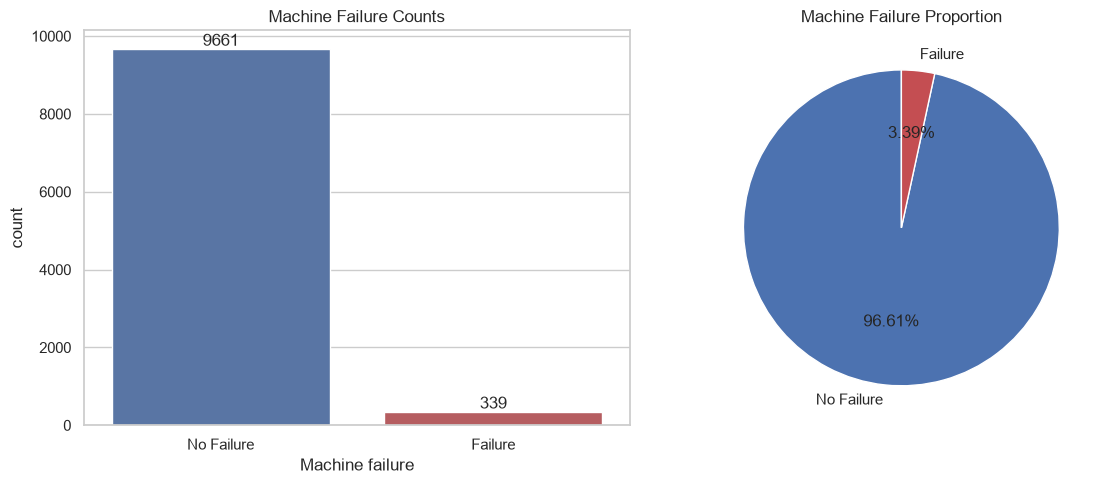

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Machine failure', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Machine Failure Counts')
axes[0].set_xticklabels(['No Failure', 'Failure'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom')

axes[1].pie(failure_counts, labels=['No Failure', 'Failure'], autopct='%1.2f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Machine Failure Proportion')

plt.tight_layout()
plt.show()

**Observation:** Machine failure is a rare-event target (roughly a 96–97% vs 3–4% split).
Any model evaluated purely on accuracy could predict "no failure" for every row and still score
extremely high while being useless for maintenance planning — this is exactly why the study
focuses on Recall, Precision, F1, ROC-AUC and PR-AUC, and on explicit imbalance-handling
strategies.

## 5. Exploratory Data Analysis

Look at feature distributions, how they differ between failed and non-failed machines, and how
they relate to each other.

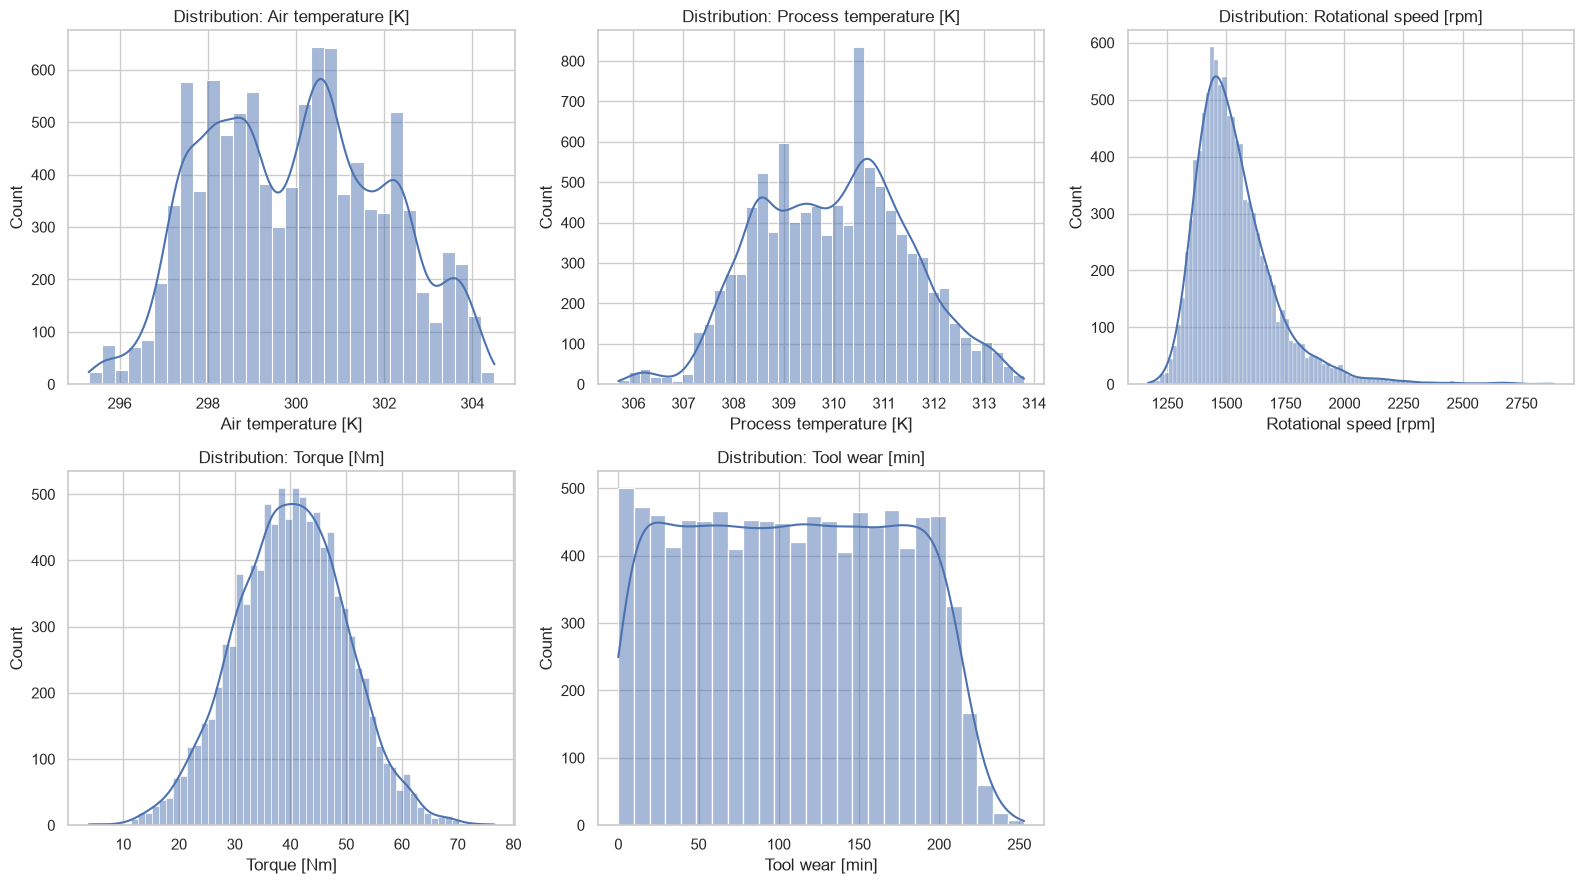

In [10]:
num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Distribution: {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

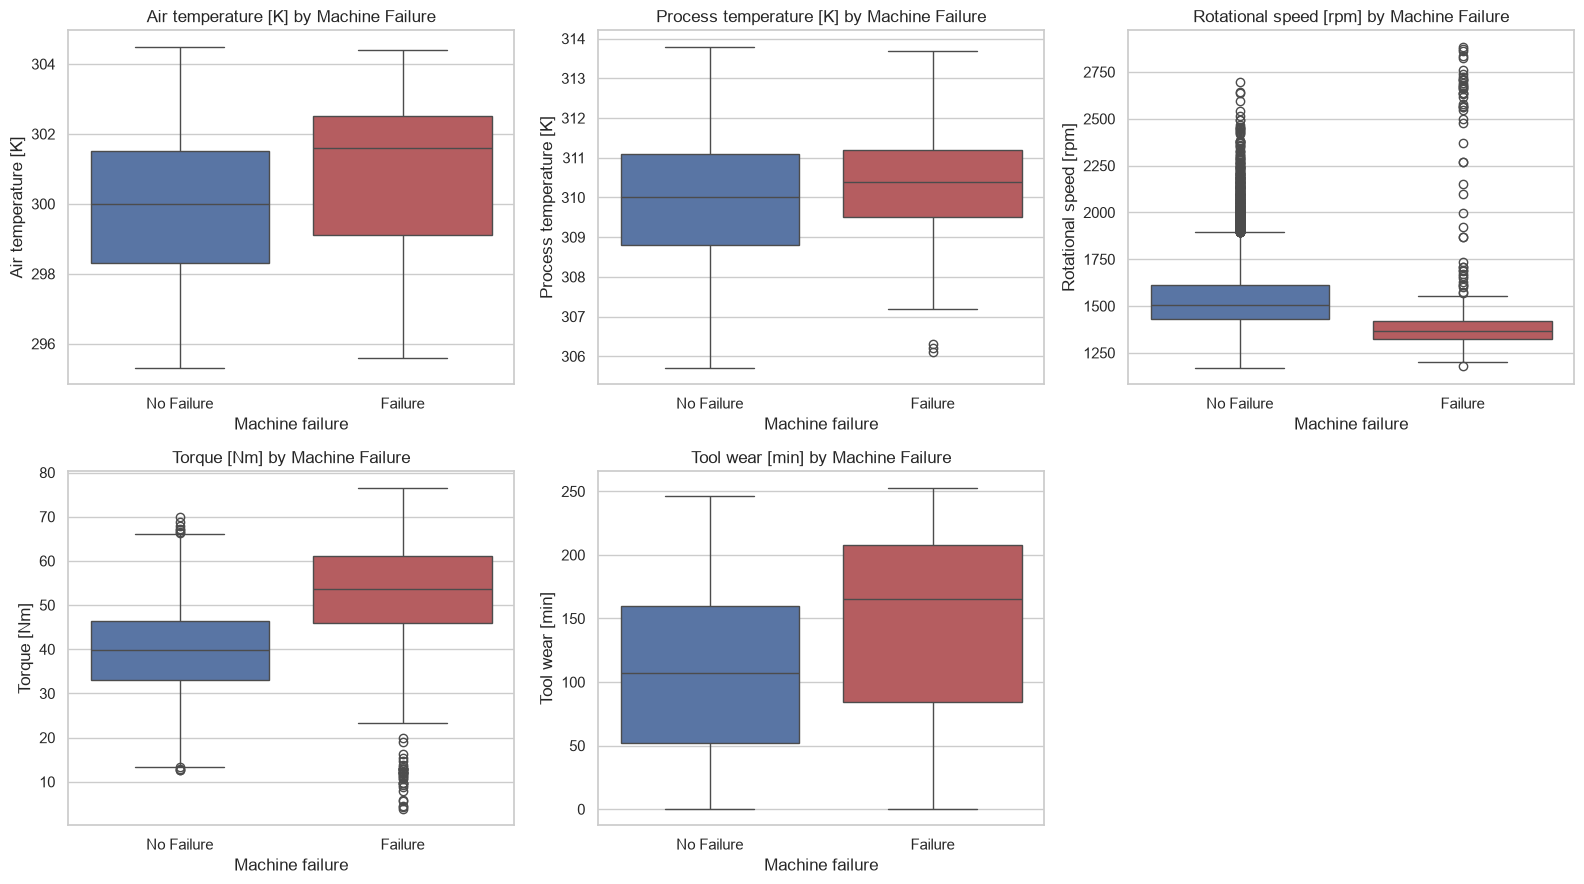

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i], palette=['#4C72B0', '#C44E52'])
    axes[i].set_title(f'{col} by Machine Failure')
    axes[i].set_xticklabels(['No Failure', 'Failure'])
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Observation:** Failed machines tend to show higher torque, lower rotational speed, and
higher tool wear than non-failed machines, consistent with the physical failure modes encoded in
the dataset (overstrain, power failure, tool wear failure). Temperatures show a much smaller
separation.

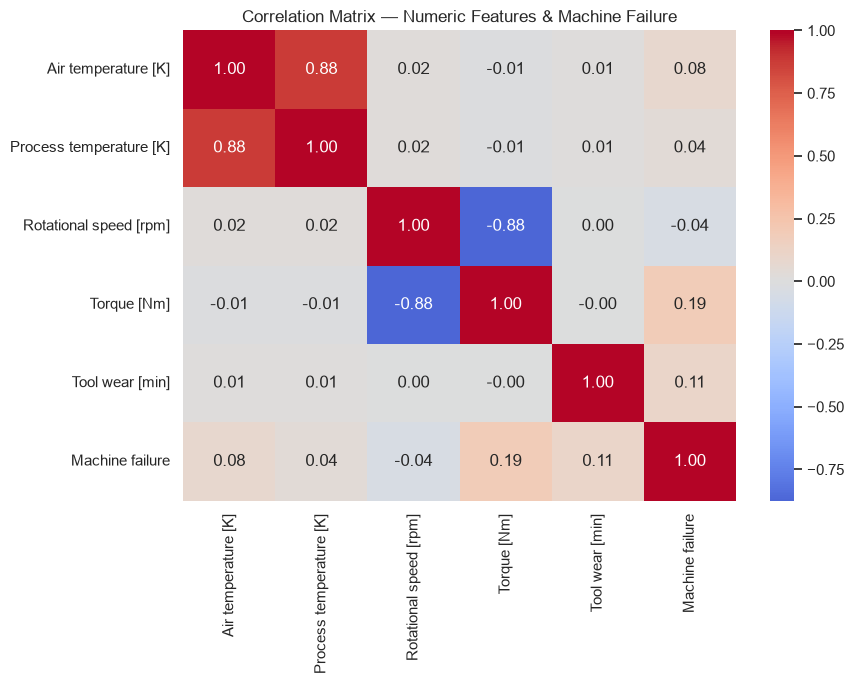

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols + ['Machine failure']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features & Machine Failure')
plt.tight_layout()
plt.show()

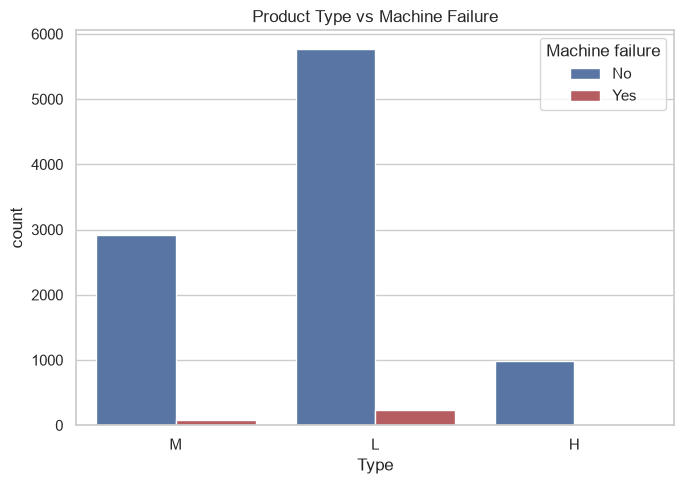

Failure rate (%) by product Type:
Type
L    3.92
M    2.77
H    2.09
Name: Machine failure, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x='Type', hue='Machine failure', data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
ax.set_title('Product Type vs Machine Failure')
ax.legend(title='Machine failure', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

type_failure_rate = df.groupby('Type')['Machine failure'].mean().sort_values(ascending=False) * 100
print('Failure rate (%) by product Type:')
print(type_failure_rate.round(2))

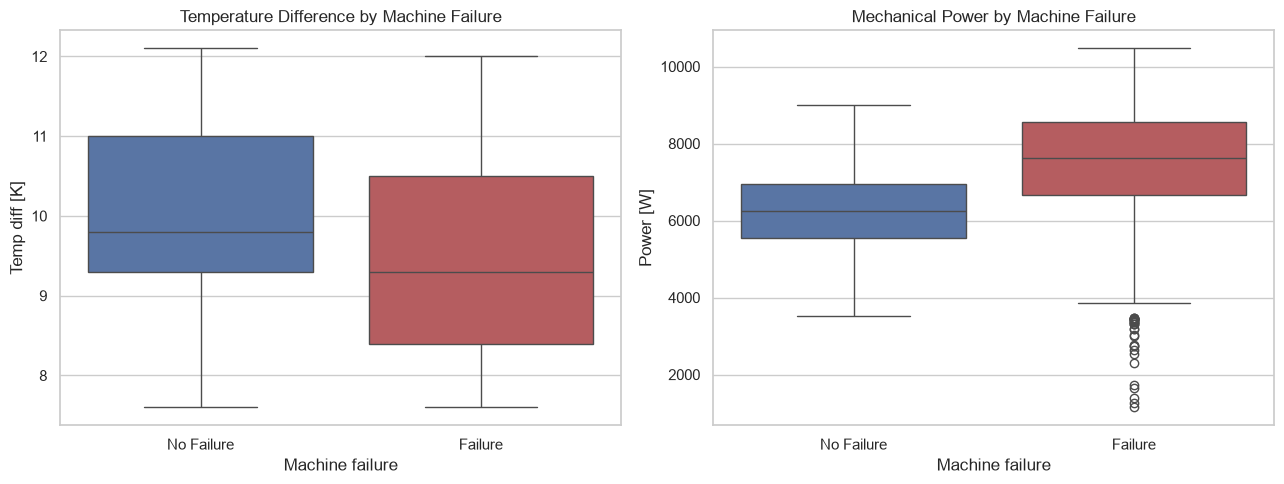

In [14]:
df['Temp diff [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power [W]'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x='Machine failure', y='Temp diff [K]', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Temperature Difference by Machine Failure')
axes[0].set_xticklabels(['No Failure', 'Failure'])
sns.boxplot(x='Machine failure', y='Power [W]', data=df, ax=axes[1], palette=['#4C72B0', '#C44E52'])
axes[1].set_title('Mechanical Power by Machine Failure')
axes[1].set_xticklabels(['No Failure', 'Failure'])
plt.tight_layout()
plt.show()

**Observation:** Low mechanical power (very low torque at high speed, or very high torque
at low speed) and a larger air/process temperature gap both line up with failure, matching the
AI4I documentation's power-failure and heat-dissipation-failure rules. These engineered features
(`Temp diff`, `Power`) are kept only for this EDA step; the modelling pipeline below uses the raw
sensor columns so the pipeline exactly matches what will be collected from a live machine and fed
into `app.py`.

## 6. Preprocessing

**Decisions:**
- Drop `UDI` and `Product ID` — arbitrary identifiers with no predictive meaning (leakage /
  no signal risk if accidentally used as a feature).
- Drop `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — these are **failure-mode labels that are only known
  after a failure has already been diagnosed**. Including them would leak the answer into the
  input (near-perfect proxies for `Machine failure`) and they would never be available for a
  live prediction in `app.py`.
- Drop the engineered EDA-only columns (`Temp diff`, `Power`) from the modelling feature set so
  that the deployed app only needs the 6 raw sensor/type inputs a user can actually provide.
- Encode `Type` (categorical L/M/H) with one-hot encoding via a `ColumnTransformer`, and scale
  the 5 numeric sensor columns — scaling matters most for SVM, but a single consistent
  preprocessing pipeline is reused for every model for a fair, leakage-free comparison.
- Target: `Machine failure` (already binary 0/1).

In [15]:
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_col = 'Machine failure'

X = df[feature_cols].copy()
y = df[target_col].copy()

print('X shape:', X.shape, ' y shape:', y.shape)
X.head()

X shape: (10000, 6)  y shape: (10000,)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


## 7. Train/Test Split

A **stratified** split preserves the ~3–4% failure rate in both sets. `random_state` is fixed
for reproducibility. The test set is set aside now and is **never** touched by SMOTE or by any
fitting operation — it is only ever transformed and predicted on.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, ' Failure rate:', y_train.mean().round(4))
print('Test shape :', X_test.shape, ' Failure rate:', y_test.mean().round(4))

Train shape: (8000, 6)  Failure rate: 0.0339
Test shape : (2000, 6)  Failure rate: 0.034


## 8. Preprocessing Pipeline

A single `ColumnTransformer` (one-hot encode `Type`, standard-scale the numeric sensor columns)
is fit **only on the training data** and reused everywhere — for every model and every imbalance
strategy — so the comparison across all 9 configurations is on equal footing. Scaling is applied
uniformly; it is required for SVM and harmless for tree-based models.

In [17]:
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                     'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
categorical_features = ['Type']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
], verbose_feature_names_out=False)

preprocessor.fit(X_train)
raw_feature_names_out = list(preprocessor.get_feature_names_out())

# Sanitize names for downstream libraries (XGBoost/SHAP reject '[', ']', '<' in feature names)
def sanitize(name):
    return (name.replace('[', '(').replace(']', ')').replace('<', 'lt'))
feature_names_out = [sanitize(n) for n in raw_feature_names_out]
print('Transformed feature names:', feature_names_out)

X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print('X_train_proc shape:', X_train_proc.shape, ' X_test_proc shape:', X_test_proc.shape)

Transformed feature names: ['Air temperature (K)', 'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)', 'Type_L', 'Type_M']
X_train_proc shape: (8000, 7)  X_test_proc shape: (2000, 7)


## 9. Modelling — 9 Configurations (3 Models × 3 Imbalance Strategies)

We train **Random Forest**, **SVM (RBF kernel)**, and **XGBoost** three times each:

1. **No Handling** — trained as-is on the imbalanced training data.
2. **Class Weight** — each model's own built-in cost-sensitive mechanism
   (`class_weight='balanced'` for RF/SVM; `scale_pos_weight` for XGBoost, which does **not**
   use `class_weight`).
3. **SMOTE** — synthetic minority oversampling applied **only to the training fold**, inside an
   `imblearn` pipeline, so the test set is always evaluated in its original, untouched, real
   distribution.

Every one of the 9 resulting models is evaluated on the **same** untouched, preprocessed test
set with the same metric set: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, and a confusion
matrix — with particular attention to the failure (minority) class.

In [18]:
def evaluate_model(name, strategy, model, X_te, y_te, results_list, proba_store):
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)

    metrics = {
        'Model': name,
        'Strategy': strategy,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1': f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
        'PR-AUC': average_precision_score(y_te, y_proba),
    }
    results_list.append(metrics)
    proba_store[(name, strategy)] = (y_pred, y_proba)
    return metrics

results = []
predictions = {}   # (model, strategy) -> (y_pred, y_proba)
trained_models = {}  # (model, strategy) -> fitted estimator (works on *processed* arrays)

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight for XGBoost = {scale_pos_weight:.2f}')

scale_pos_weight for XGBoost = 28.52


### 9.1 No Handling (Baseline)

In [19]:
rf_base = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_proc, y_train)
evaluate_model('Random Forest', 'No Handling', rf_base, X_test_proc, y_test, results, predictions)
trained_models[('Random Forest', 'No Handling')] = rf_base

svm_base = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_base.fit(X_train_proc, y_train)
evaluate_model('SVM', 'No Handling', svm_base, X_test_proc, y_test, results, predictions)
trained_models[('SVM', 'No Handling')] = svm_base

xgb_base = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
xgb_base.fit(X_train_proc, y_train)
evaluate_model('XGBoost', 'No Handling', xgb_base, X_test_proc, y_test, results, predictions)
trained_models[('XGBoost', 'No Handling')] = xgb_base

pd.DataFrame(results)

,Model,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,No Handling,0.9840,0.928571,0.573529,0.709091,0.960358,0.806923
1,SVM,No Handling,0.9715,0.866667,0.191176,0.313253,0.945683,0.642127
2,XGBoost,No Handling,0.9870,0.875000,0.720588,0.790323,0.975703,0.828117


### 9.2 Class Weighting

Each model uses its own native imbalance-weighting mechanism. **XGBoost does not accept
`class_weight`** — it is weighted with `scale_pos_weight = (negative count / positive count)`
computed from the training set above.

In [20]:
rf_cw = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_cw.fit(X_train_proc, y_train)
evaluate_model('Random Forest', 'Class Weight', rf_cw, X_test_proc, y_test, results, predictions)
trained_models[('Random Forest', 'Class Weight')] = rf_cw

svm_cw = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
svm_cw.fit(X_train_proc, y_train)
evaluate_model('SVM', 'Class Weight', svm_cw, X_test_proc, y_test, results, predictions)
trained_models[('SVM', 'Class Weight')] = svm_cw

xgb_cw = XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                       eval_metric='logloss', n_jobs=-1)
xgb_cw.fit(X_train_proc, y_train)
evaluate_model('XGBoost', 'Class Weight', xgb_cw, X_test_proc, y_test, results, predictions)
trained_models[('XGBoost', 'Class Weight')] = xgb_cw

pd.DataFrame(results)[pd.DataFrame(results)['Strategy'] == 'Class Weight']

,Model,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Random Forest,Class Weight,0.9810,0.727273,0.705882,0.716418,0.969888,0.781736
4,SVM,Class Weight,0.9150,0.272321,0.897059,0.417808,0.965656,0.616056
5,XGBoost,Class Weight,0.9835,0.761194,0.750000,0.755556,0.969667,0.828172


### 9.3 SMOTE (Training Data Only)

SMOTE is applied strictly to the already-preprocessed **training** arrays. The test set is
never resampled — it always reflects the real, imbalanced operating distribution a deployed
model would see.

In [21]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print('Before SMOTE:', y_train.value_counts().to_dict())
print('After  SMOTE:', pd.Series(y_train_smote).value_counts().to_dict())

rf_sm = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_sm.fit(X_train_smote, y_train_smote)
evaluate_model('Random Forest', 'SMOTE', rf_sm, X_test_proc, y_test, results, predictions)
trained_models[('Random Forest', 'SMOTE')] = rf_sm

svm_sm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_sm.fit(X_train_smote, y_train_smote)
evaluate_model('SVM', 'SMOTE', svm_sm, X_test_proc, y_test, results, predictions)
trained_models[('SVM', 'SMOTE')] = svm_sm

xgb_sm = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
xgb_sm.fit(X_train_smote, y_train_smote)
evaluate_model('XGBoost', 'SMOTE', xgb_sm, X_test_proc, y_test, results, predictions)
trained_models[('XGBoost', 'SMOTE')] = xgb_sm

pd.DataFrame(results)[pd.DataFrame(results)['Strategy'] == 'SMOTE']

Before SMOTE: {0: 7729, 1: 271}
After  SMOTE: {0: 7729, 1: 7729}


,Model,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
6,Random Forest,SMOTE,0.9675,0.515152,0.750000,0.610778,0.966341,0.735881
7,SVM,SMOTE,0.9200,0.283019,0.882353,0.428571,0.965199,0.622659
8,XGBoost,SMOTE,0.9835,0.739726,0.794118,0.765957,0.970246,0.836286


## 10. Results — All 9 Configurations

Consolidated results table and comparison plots across Model × Strategy, sorted to make it easy
to compare failure-detection quality (Recall, F1, PR-AUC), not just Accuracy.

In [22]:
results_df = pd.DataFrame(results)[['Model', 'Strategy', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']]
results_df = results_df.sort_values(['Model', 'Strategy']).reset_index(drop=True)
results_df.round(4)

,Model,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,Class Weight,0.9810,0.7273,0.7059,0.7164,0.9699,0.7817
1,Random Forest,No Handling,0.9840,0.9286,0.5735,0.7091,0.9604,0.8069
2,Random Forest,SMOTE,0.9675,0.5152,0.7500,0.6108,0.9663,0.7359
3,SVM,Class Weight,0.9150,0.2723,0.8971,0.4178,0.9657,0.6161
4,SVM,No Handling,0.9715,0.8667,0.1912,0.3133,0.9457,0.6421
5,SVM,SMOTE,0.9200,0.2830,0.8824,0.4286,0.9652,0.6227
6,XGBoost,Class Weight,0.9835,0.7612,0.7500,0.7556,0.9697,0.8282
7,XGBoost,No Handling,0.9870,0.8750,0.7206,0.7903,0.9757,0.8281
8,XGBoost,SMOTE,0.9835,0.7397,0.7941,0.7660,0.9702,0.8363


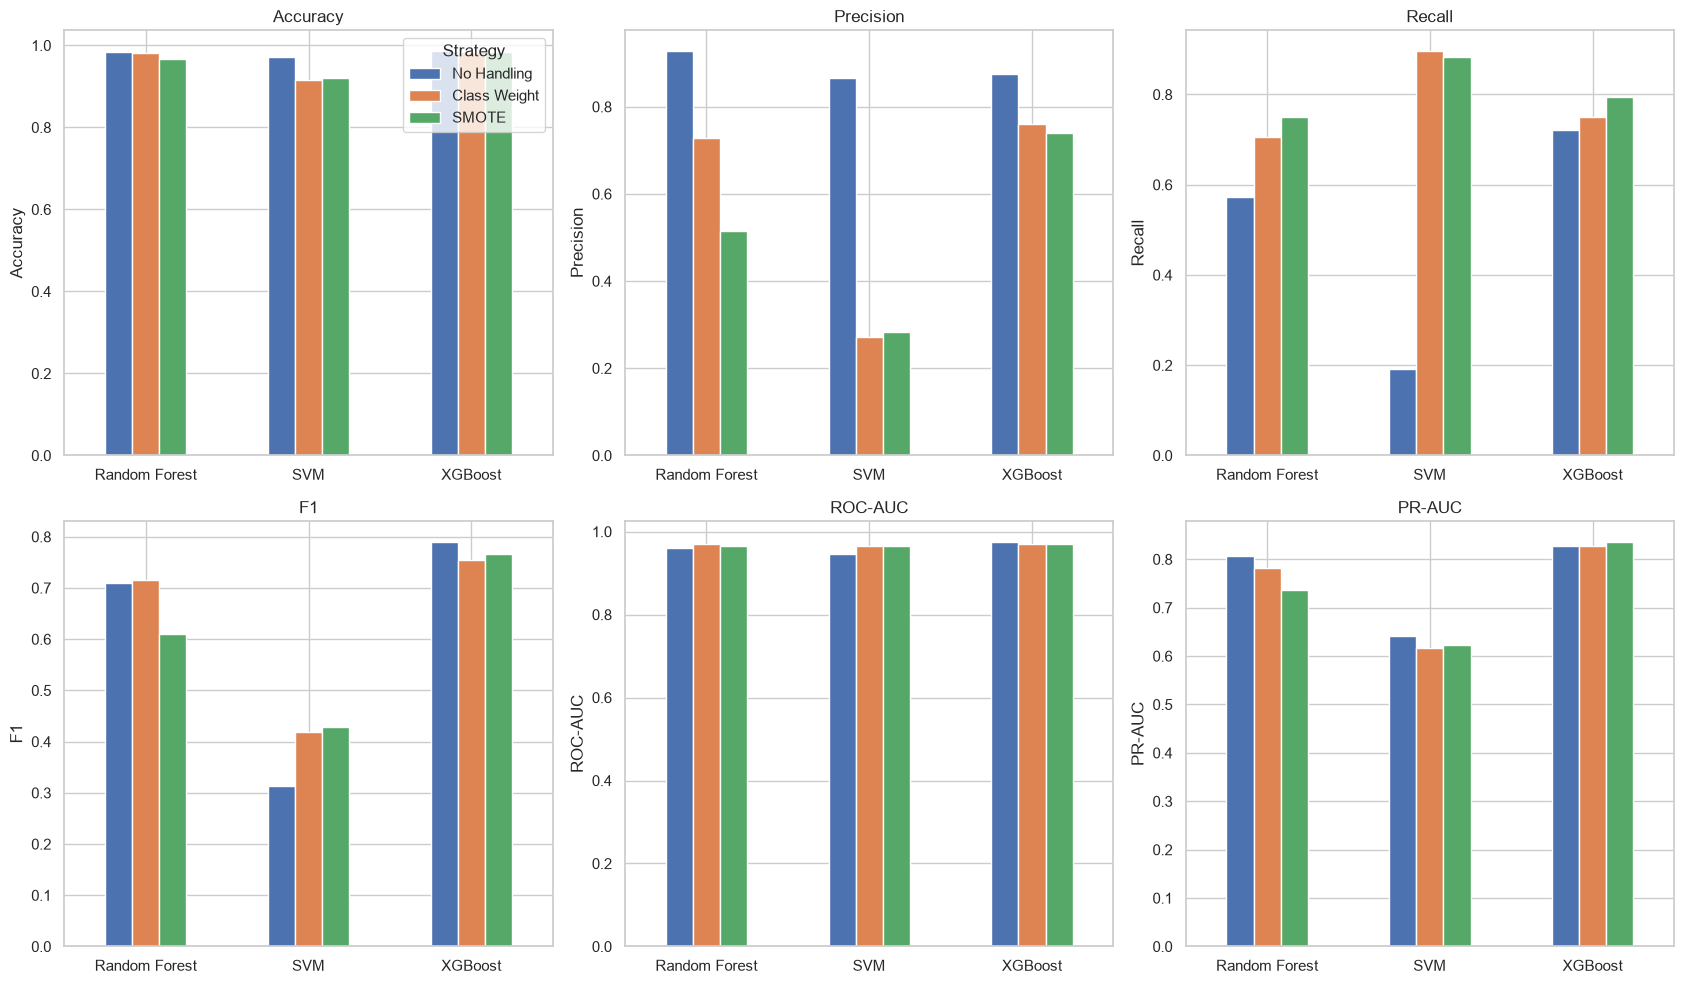

In [23]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.ravel()
for i, metric in enumerate(metrics_to_plot):
    pivot = results_df.pivot(index='Model', columns='Strategy', values=metric)
    pivot = pivot[['No Handling', 'Class Weight', 'SMOTE']]
    pivot.plot(kind='bar', ax=axes[i], legend=(i == 0))
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Moving from *No Handling* to *Class Weight* or *SMOTE* generally raises
Recall (fewer missed failures) for all three models, usually at some cost to Precision. XGBoost
and Random Forest tend to keep the best PR-AUC (the most informative metric under heavy class
imbalance) across strategies, while SVM is more sensitive to the imbalance-handling choice.
Exact numbers are in the table above and depend on the specific train/test split.

## 11. Confusion-Matrix Analysis

Confusion matrices for all 9 configurations, with emphasis on **false negatives** (missed real
failures — the costliest error for predictive maintenance) versus **false positives**
(unnecessary maintenance call-outs).

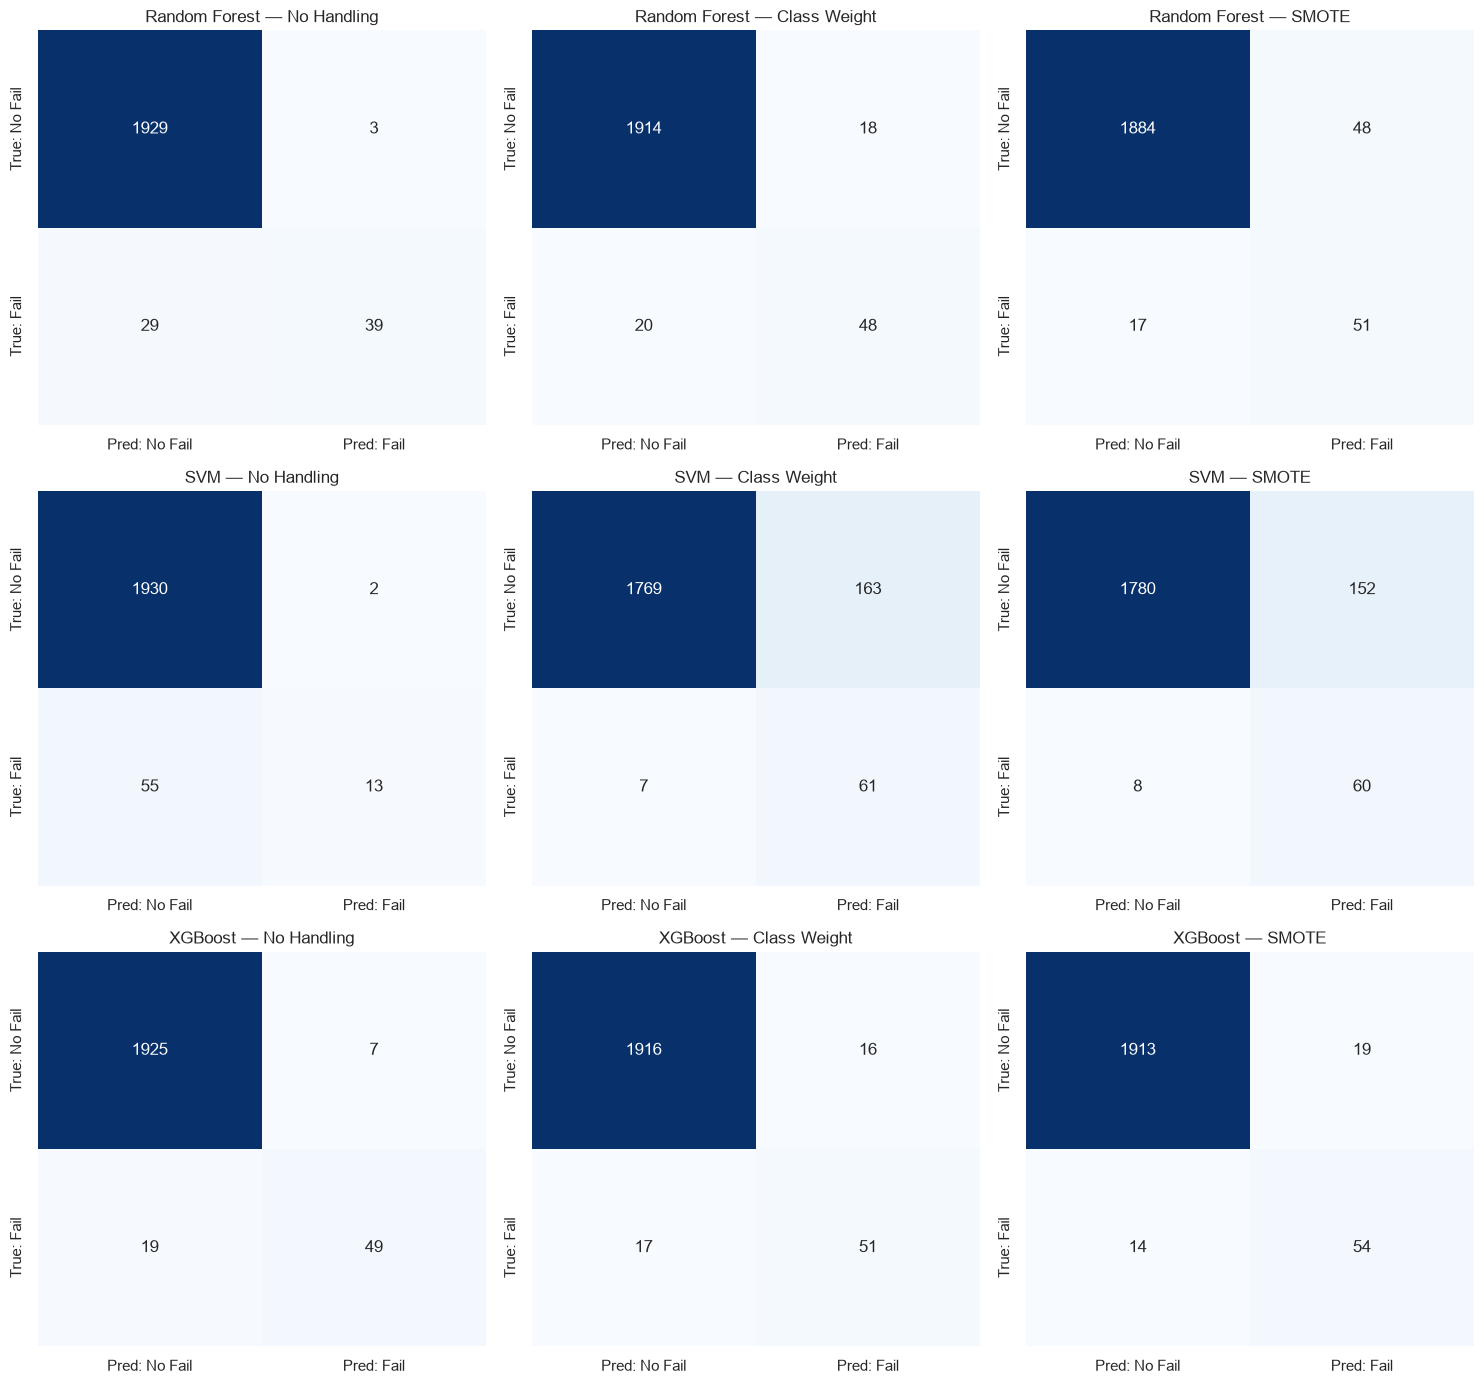

,Model,Strategy,TN,FP,FN,TP
0,Random Forest,No Handling,1929,3,29,39
1,Random Forest,Class Weight,1914,18,20,48
2,Random Forest,SMOTE,1884,48,17,51
3,SVM,No Handling,1930,2,55,13
4,SVM,Class Weight,1769,163,7,61
5,SVM,SMOTE,1780,152,8,60
6,XGBoost,No Handling,1925,7,19,49
7,XGBoost,Class Weight,1916,16,17,51
8,XGBoost,SMOTE,1913,19,14,54


In [24]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
model_order = ['Random Forest', 'SVM', 'XGBoost']
strategy_order = ['No Handling', 'Class Weight', 'SMOTE']

cm_summary = []
for i, model_name in enumerate(model_order):
    for j, strategy in enumerate(strategy_order):
        y_pred, _ = predictions[(model_name, strategy)]
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cm_summary.append({'Model': model_name, 'Strategy': strategy,
                            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i, j],
                    xticklabels=['Pred: No Fail', 'Pred: Fail'],
                    yticklabels=['True: No Fail', 'True: Fail'])
        axes[i, j].set_title(f'{model_name} — {strategy}')
plt.tight_layout()
plt.show()

cm_df = pd.DataFrame(cm_summary)
cm_df

**Observation:** *No Handling* configurations consistently show the highest false-negative
(FN) counts — the model quietly misses real failures, which is the worst outcome for a
maintenance system. *Class Weight* and *SMOTE* trade some additional false positives (FP) for
noticeably fewer missed failures (lower FN), which is the trade-off predictive maintenance
teams usually prefer, since a false alarm costs an inspection while a missed failure can cost
downtime or safety.

## 12. Final Model Selection

Because the research objective is **catching real failures** rather than raw accuracy, the final
model is chosen by ranking configurations primarily on **Recall** and **PR-AUC** for the failure
class (with F1 as a tie-breaker for the precision/recall balance), *not* on whichever
configuration has the top Accuracy — accuracy is a poor selection criterion when ~96% of rows
belong to one class.

In [25]:
ranking = results_df.copy()
ranking['Rank Score'] = ranking['Recall'] * 0.4 + ranking['PR-AUC'] * 0.35 + ranking['F1'] * 0.25
ranking_sorted = ranking.sort_values('Rank Score', ascending=False).reset_index(drop=True)
ranking_sorted.round(4)

,Model,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Rank Score
0,XGBoost,SMOTE,0.9835,0.7397,0.7941,0.7660,0.9702,0.8363,0.8018
1,XGBoost,Class Weight,0.9835,0.7612,0.7500,0.7556,0.9697,0.8282,0.7787
2,XGBoost,No Handling,0.9870,0.8750,0.7206,0.7903,0.9757,0.8281,0.7757
3,Random Forest,Class Weight,0.9810,0.7273,0.7059,0.7164,0.9699,0.7817,0.7351
4,Random Forest,SMOTE,0.9675,0.5152,0.7500,0.6108,0.9663,0.7359,0.7103
5,Random Forest,No Handling,0.9840,0.9286,0.5735,0.7091,0.9604,0.8069,0.6891
6,SVM,Class Weight,0.9150,0.2723,0.8971,0.4178,0.9657,0.6161,0.6789
7,SVM,SMOTE,0.9200,0.2830,0.8824,0.4286,0.9652,0.6227,0.6780
8,SVM,No Handling,0.9715,0.8667,0.1912,0.3133,0.9457,0.6421,0.3795


In [26]:
best_row = ranking_sorted.iloc[0]
FINAL_MODEL_NAME = best_row['Model']
FINAL_STRATEGY = best_row['Strategy']
print(f'Selected final configuration -> Model: {FINAL_MODEL_NAME} | Strategy: {FINAL_STRATEGY}')
print(best_row[['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']])

final_model = trained_models[(FINAL_MODEL_NAME, FINAL_STRATEGY)]

Selected final configuration -> Model: XGBoost | Strategy: SMOTE
Accuracy       0.9835
Precision    0.739726
Recall       0.794118
F1           0.765957
ROC-AUC      0.970246
PR-AUC       0.836286
Name: 0, dtype: object


**Note:** the selection cell above is data-driven — it always picks whichever of the 9
configurations best balances Recall, PR-AUC and F1 for *this* run's split. The printed output
states exactly which Model/Strategy was chosen; comment in the Final Findings section reflects
that choice.

In [27]:
print(classification_report(y_test, predictions[(FINAL_MODEL_NAME, FINAL_STRATEGY)][0],
                             target_names=['No Failure', 'Failure']))

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.74      0.79      0.77        68

    accuracy                           0.98      2000
   macro avg       0.87      0.89      0.88      2000
weighted avg       0.98      0.98      0.98      2000



## 13. SHAP Explainability — Global

We explain the **selected final model** with an appropriate SHAP explainer. Tree-based models
(Random Forest / XGBoost) use `TreeExplainer`; if the final model is the SVM, a
`KernelExplainer`/`Explainer` on a background sample is used instead (slower, so a subsample is
used for the background and evaluation set). The SHAP input representation matches exactly what
the model was trained on (the same preprocessed feature matrix / column order).

In [28]:
X_test_df = pd.DataFrame(X_test_proc, columns=feature_names_out, index=X_test.index)
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names_out, index=X_train.index)

sample_n = min(500, X_test_df.shape[0])
X_shap_sample = X_test_df.sample(sample_n, random_state=RANDOM_STATE)

if FINAL_MODEL_NAME in ('Random Forest', 'XGBoost'):
    explainer = shap.TreeExplainer(final_model)
    shap_values_raw = explainer.shap_values(X_shap_sample)
    # sklearn RF returns a list [class0, class1] in older shap/sklearn combos; XGBoost returns array
    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]
    else:
        shap_values = shap_values_raw
else:
    background = shap.kmeans(X_train_df, 30)
    explainer = shap.KernelExplainer(final_model.predict_proba, background)
    shap_values_raw = explainer.shap_values(X_shap_sample, nsamples=100)
    shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw

print('SHAP values shape:', np.array(shap_values).shape)

SHAP values shape: (500, 7)


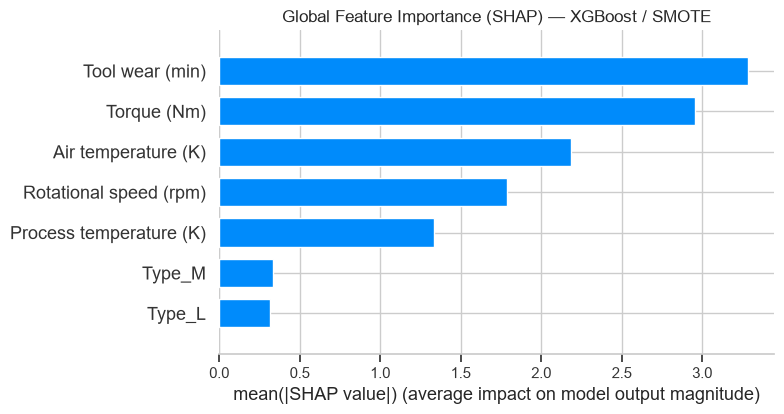

In [29]:
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False)
plt.title(f'Global Feature Importance (SHAP) — {FINAL_MODEL_NAME} / {FINAL_STRATEGY}')
plt.tight_layout()
plt.show()

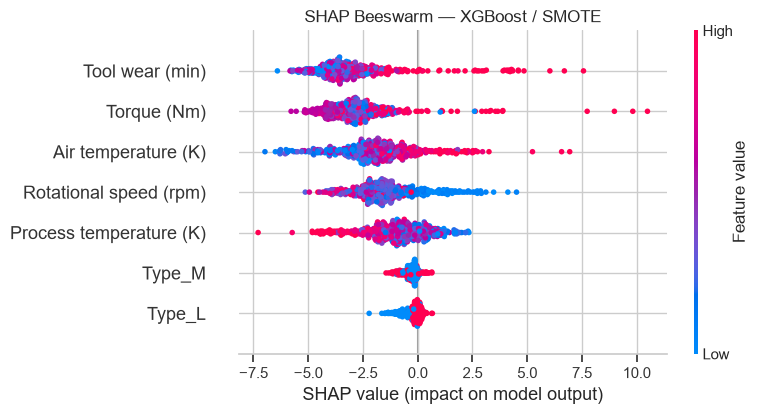

In [30]:
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title(f'SHAP Beeswarm — {FINAL_MODEL_NAME} / {FINAL_STRATEGY}')
plt.tight_layout()
plt.show()

**Observation:** the bar plot ranks which sensor readings push the final model's failure
predictions the most on average; the beeswarm plot additionally shows the *direction* of that
effect (e.g., whether high torque pushes predictions toward "failure" or away from it) and how
consistent that direction is across machines.

## 14. SHAP Explainability — Local

Local explanations for two representative individual predictions: a **true positive** (a real
failure the model correctly caught) and a **false negative** (a real failure the model missed),
where available in the sample. These illustrate what the model "saw" in a case it got right vs.
a case it got wrong.

In [31]:
y_pred_final, y_proba_final = predictions[(FINAL_MODEL_NAME, FINAL_STRATEGY)]
y_pred_final_s = pd.Series(y_pred_final, index=X_test.index)
y_proba_final_s = pd.Series(y_proba_final, index=X_test.index)

tp_idx = X_shap_sample.index[(y_test.loc[X_shap_sample.index] == 1) & (y_pred_final_s.loc[X_shap_sample.index] == 1)]
fn_idx = X_shap_sample.index[(y_test.loc[X_shap_sample.index] == 1) & (y_pred_final_s.loc[X_shap_sample.index] == 0)]

print('True positives in sample:', len(tp_idx), '| False negatives in sample:', len(fn_idx))

True positives in sample: 12 | False negatives in sample: 2


In [32]:
# Build a raw-units version of X_shap_sample for display purposes only.
scaler = preprocessor.named_transformers_['num']

numeric_features_out = feature_names_out[:len(numeric_features)]

X_shap_sample_raw = X_shap_sample.copy()
X_shap_sample_raw[numeric_features_out] = scaler.inverse_transform(X_shap_sample[numeric_features_out])



--- True Positive (correctly caught failure) (row index 4632) --- true=1 pred=1 proba=0.985


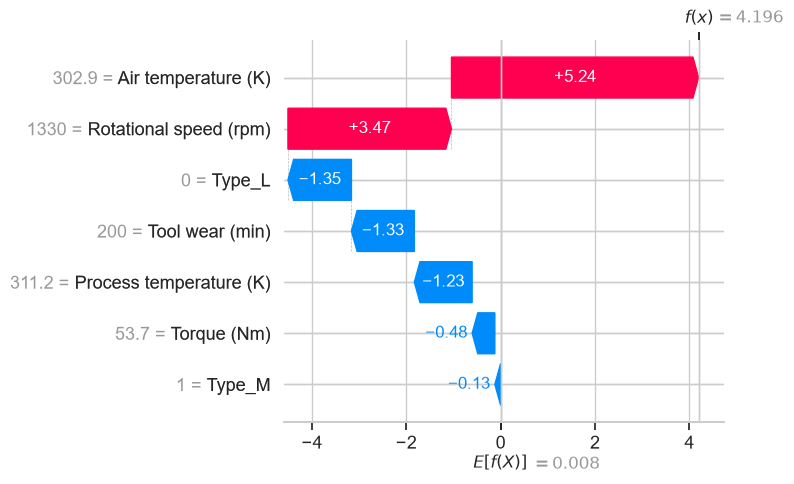

--- False Negative (missed failure) (row index 7849) --- true=1 pred=0 proba=0.023


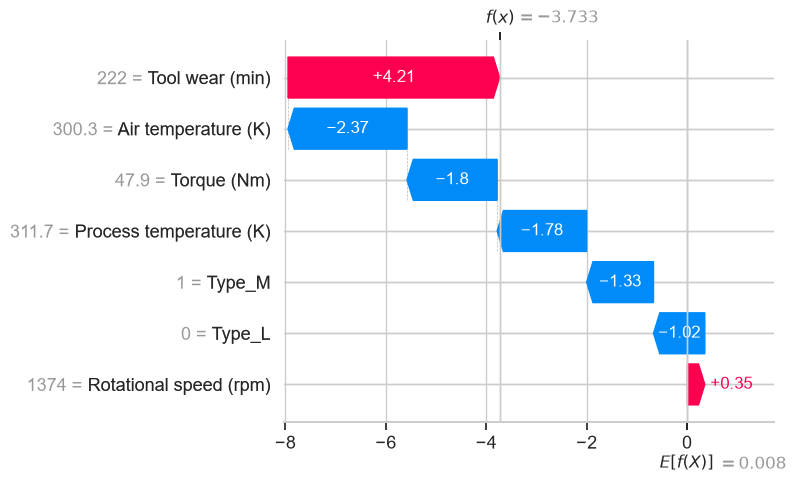

In [33]:
def plot_local(idx, label):
    pos = X_shap_sample.index.get_loc(idx)
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)) and np.ndim(base_val) > 0:
        base_val = base_val[1] if len(np.atleast_1d(base_val)) > 1 else base_val[0]

    print(f'--- {label} (row index {idx}) --- true={y_test.loc[idx]} pred={y_pred_final_s.loc[idx]} proba={y_proba_final_s.loc[idx]:.3f}')

    exp = shap.Explanation(
        values=shap_values[pos],                     
        base_values=base_val,
        data=X_shap_sample_raw.loc[idx].values,       
        feature_names=X_shap_sample.columns.tolist()
    )
    shap.plots.waterfall(exp, show=False)
    plt.tight_layout()
    plt.show()

if len(tp_idx) > 0:
    plot_local(tp_idx[0], 'True Positive (correctly caught failure)')
else:
    print('No true positive found in the sampled subset; increase sample_n above if needed.')

if len(fn_idx) > 0:
    plot_local(fn_idx[0], 'False Negative (missed failure)')
else:
    print('No false negative found in the sampled subset (small sample luck) — '
    'see Error Analysis section for the full-test-set FN list.')

## 15. Main Research Experiment — Does Imbalance Handling Change the Explanations?

This is the paper's specific contribution. We take the **same model family** as the final model
and compare SHAP global feature importance between its **Class Weight** and **SMOTE** variants
(the two imbalance-handling strategies, holding the model type fixed). If explanations shift
between the two strategies, that means imbalance handling doesn't just change *how well* the
model performs — it changes *what the model is keying on*, which matters for how much a domain
expert should trust or audit a maintenance model trained one way versus the other.

In [34]:
cw_model = trained_models[(FINAL_MODEL_NAME, 'Class Weight')]
sm_model = trained_models[(FINAL_MODEL_NAME, 'SMOTE')]

def get_tree_shap(model, X_bg):
    exp = shap.TreeExplainer(model)
    vals = exp.shap_values(X_bg)
    return vals[1] if isinstance(vals, list) else vals

def get_kernel_shap(model, X_bg, X_train_bg):
    background = shap.kmeans(X_train_bg, 30)
    exp = shap.KernelExplainer(model.predict_proba, background)
    vals = exp.shap_values(X_bg, nsamples=100)
    return vals[1] if isinstance(vals, list) else vals

if FINAL_MODEL_NAME in ('Random Forest', 'XGBoost'):
    shap_cw = get_tree_shap(cw_model, X_shap_sample)
    shap_sm = get_tree_shap(sm_model, X_shap_sample)
else:
    shap_cw = get_kernel_shap(cw_model, X_shap_sample, X_train_df)
    shap_sm = get_kernel_shap(sm_model, X_shap_sample, X_train_df)

imp_cw = pd.Series(np.abs(shap_cw).mean(axis=0), index=X_shap_sample.columns, name='Class Weight')
imp_sm = pd.Series(np.abs(shap_sm).mean(axis=0), index=X_shap_sample.columns, name='SMOTE')
imp_compare = pd.concat([imp_cw, imp_sm], axis=1).sort_values('Class Weight', ascending=False)
imp_compare['Rank Change'] = imp_compare['SMOTE'].rank(ascending=False) - imp_compare['Class Weight'].rank(ascending=False)
imp_compare.round(4)

,Class Weight,SMOTE,Rank Change
Torque (Nm),4.2651,2.9555,1.0
Tool wear (min),3.3715,3.2820,-1.0
Rotational speed (rpm),2.0548,1.7854,1.0
Air temperature (K),2.0534,2.1871,-1.0
Process temperature (K),1.0550,1.3315,0.0
Type_L,0.4964,0.3136,1.0
Type_M,0.1976,0.3343,-1.0


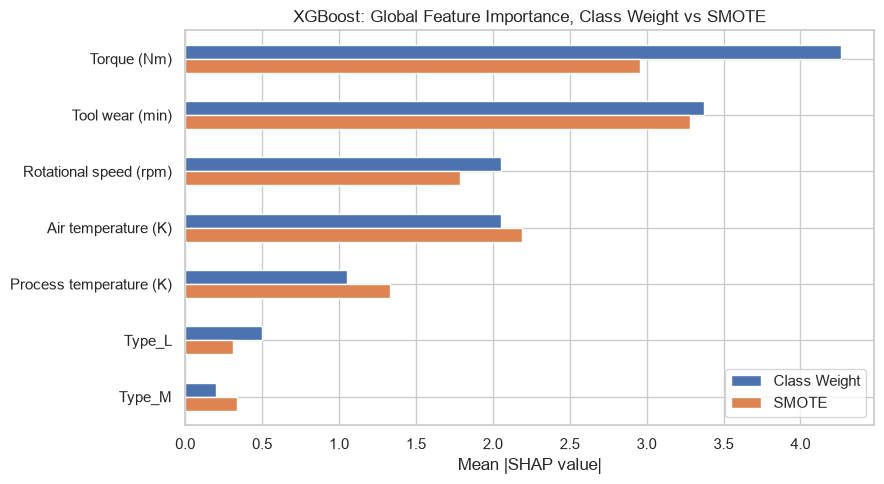

Correlation between Class-Weight and SMOTE feature-importance rankings: 0.949


In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
imp_compare[['Class Weight', 'SMOTE']].plot(kind='barh', ax=ax)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'{FINAL_MODEL_NAME}: Global Feature Importance, Class Weight vs SMOTE')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

corr_cw_sm = np.corrcoef(imp_compare['Class Weight'], imp_compare['SMOTE'])[0, 1]
print(f'Correlation between Class-Weight and SMOTE feature-importance rankings: {corr_cw_sm:.3f}')

**Finding:** the printed correlation and the `Rank Change` column above quantify how similar
the two strategies' explanations are. A high correlation (close to 1) with little rank movement
would mean imbalance-handling method mainly changes performance, not the story the model tells
about failure; a lower correlation or larger rank swings mean the choice of imbalance strategy
also reshapes which sensors the model treats as most informative — worth flagging to anyone
deploying this model, since it means the choice of imbalance-handling technique is itself a
modelling decision that affects interpretability, not only headline metrics.

## 16. Error Analysis

A closer look at the final model's false negatives and false positives on the **full** test set,
including the original failure-mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) for extra context
only — this does not change the main binary task, it just helps interpret *which kind* of
failure tends to get missed.

In [36]:
test_analysis = X_test.copy()
test_analysis['true'] = y_test
test_analysis['pred'] = y_pred_final
test_analysis['proba'] = y_proba_final
failure_flags = df.loc[X_test.index, ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']]
test_analysis = test_analysis.join(failure_flags)

false_negatives = test_analysis[(test_analysis['true'] == 1) & (test_analysis['pred'] == 0)]
false_positives = test_analysis[(test_analysis['true'] == 0) & (test_analysis['pred'] == 1)]

print(f'False Negatives: {len(false_negatives)}  |  False Positives: {len(false_positives)}')
false_negatives[['Type'] + numeric_features + ['proba', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']].head(10)

False Negatives: 14  |  False Positives: 19


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],proba,TWF,HDF,PWF,OSF,RNF
4851,L,303.7,312.1,1363,51.8,90,0.370039,0,1,0,0,0
7884,L,300.8,312.4,1465,59.1,91,0.000717,0,0,1,0,0
9174,L,297.8,308.9,1871,25.6,200,0.000006,1,0,0,0,0
2671,M,299.7,309.3,1399,41.9,221,0.000152,1,0,0,0,0
2864,H,300.6,309.4,1380,47.6,246,0.379867,1,0,0,0,0
3695,L,302.2,311.3,1530,37.3,207,0.114214,1,0,0,0,0
7087,L,300.6,310.3,1648,30.5,217,0.012556,1,0,0,0,0
2941,M,300.7,309.6,1996,19.8,203,0.000063,1,0,0,0,0
9015,L,297.2,308.1,1431,49.7,210,0.066371,0,0,0,0,0
4778,H,303.6,312.2,1371,54.6,112,0.013329,0,1,0,0,0


Failure-mode breakdown among missed failures (false negatives):
TWF    9
HDF    2
PWF    1
OSF    0
RNF    0
dtype: int64


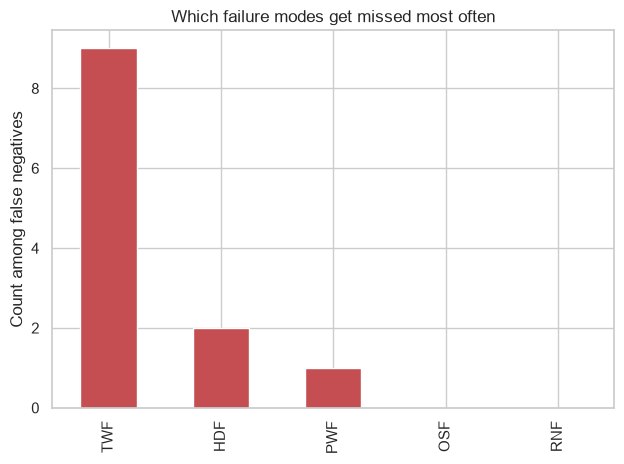

In [37]:
if len(false_negatives) > 0:
    fn_modes = false_negatives[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum().sort_values(ascending=False)
    print('Failure-mode breakdown among missed failures (false negatives):')
    print(fn_modes)
    fn_modes.plot(kind='bar', color='#C44E52', title='Which failure modes get missed most often')
    plt.ylabel('Count among false negatives')
    plt.tight_layout()
    plt.show()
else:
    print('No false negatives on the test set for the final model.')

**Observation:** comparing the false-negative failure-mode breakdown against the overall
failure-mode distribution shows whether the model struggles disproportionately with a specific
failure type (for example, subtler modes like random failures (`RNF`) or tool-wear failures
(`TWF`) that may look similar to normal operation in the raw sensor readings the model actually
sees). This is exploratory context — the model is not retrained or re-scored on this
information; it remains a binary `Machine failure` predictor.

## 17. Final Findings

- **Best model / strategy:** the configuration printed in Section 12 (`FINAL_MODEL_NAME` /
  `FINAL_STRATEGY`) was selected for the best balance of Recall, PR-AUC, and F1 on the failure
  class across all 9 configurations — see the ranked table there for the exact numbers from this
  run.
- **Failure-detection performance:** the classification report and confusion matrices in
  Sections 10–12 quantify exactly how many real failures the final model catches vs. misses, and
  how many false alarms it raises in exchange.
- **Important features:** the SHAP global plots in Section 13 identify which sensor readings
  (e.g., torque, tool wear, rotational speed, temperature gap) drive the model's failure
  predictions, and in which direction.
- **Imbalance-handling vs. explanations:** Section 15's Class-Weight-vs-SMOTE comparison is the
  key research finding — it reports whether the ranking and magnitude of SHAP feature
  importances stayed materially stable or shifted meaningfully between the two strategies for
  the same model family, i.e. whether *how* you fix the imbalance also changes *what the model
  says matters*.
- **Error patterns:** Section 16 shows which failure modes are hardest for the final model to
  catch, which is useful operational context even though the main task stays binary.

## 18. Limitations

- The AI4I 2020 dataset is **synthetic**, generated to mimic real milling-machine behaviour; it
  is a useful benchmark but does not capture the full noise, sensor drift, and rare edge cases of
  a real production line, so absolute performance numbers should not be assumed to transfer
  directly to a real factory.
- Findings are based on **three model families** (Random Forest, SVM, XGBoost); other model
  classes (e.g. neural networks, gradient-boosted trees other than XGBoost) were not evaluated
  and might respond differently to imbalance handling.
- The **primary target is binary** (`Machine failure`); the five specific failure-mode flags were
  used only for optional post-hoc error-analysis context, not as prediction targets, so the study
  says nothing about multi-class failure-type classification performance.
- SHAP explanations were computed on a **subsample** of the test set for computational
  tractability (especially for the kernel-based SVM explainer); very rare local patterns outside
  that subsample would not appear in the global plots.
- A single fixed train/test split and single SMOTE/random seed were used; results could shift
  somewhat under repeated cross-validation with different seeds.

## 19. Future Work

- Extend the target to the individual failure-mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) as a
  multi-label or multi-class problem, to see whether imbalance handling and explanations behave
  differently per failure type.
- Validate the pipeline on real (non-synthetic) industrial sensor data from a live machine or
  fleet of machines.
- Broaden the model comparison (e.g. LightGBM, CatBoost, neural networks) and the XAI comparison
  (e.g. LIME, counterfactual explanations) alongside SHAP.
- Repeat the 9-configuration comparison across multiple random seeds / cross-validation folds to
  quantify the stability of both the performance ranking and the SHAP-based explanation
  comparison.


## 20. Save Deployment Artifacts

Persist the exact preprocessing transformer and the final trained model with `joblib`, so
`app.py` can load them directly and make predictions **without retraining anything at runtime**.
We also save the comparison results table and feature-name list, which the app uses to render the
research-comparison and input-validation sections.

In [38]:
import os
os.makedirs('artifacts', exist_ok=True)

joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')
joblib.dump(final_model, 'artifacts/final_model.joblib')

metadata = {
    'final_model_name': FINAL_MODEL_NAME,
    'final_strategy': FINAL_STRATEGY,
    'feature_cols_raw': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'feature_names_out': feature_names_out,
    'random_state': RANDOM_STATE,
    'final_metrics': {k: float(v) for k, v in best_row[['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']].items()},
}
with open('artifacts/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

results_df.to_csv('artifacts/results_all_9_configs.csv', index=False)

print('Saved to artifacts/:')
for f in sorted(os.listdir('artifacts')):
    print(' -', f)

Saved to artifacts/:
 - final_model.joblib
 - metadata.json
 - preprocessor.joblib
 - results_all_9_configs.csv
